In [ ]:
!python setup_colab.py

# ***German Apartment Rental Price Analysis: Naive Bayes Pipeline***

## ***I. Overview***

### This section provides the foundational context of our analysis. We utilize the Immoscout24 dataset, which contains detailed information about apartment rentals in Germany. Our goal is to leverage probabilistic modeling to categorize apartments into distinct price tiers, enabling better market insights for both renters and landlords.

### The project implements the Naive Bayes algorithm to predict the price category of apartments in Germany. We explore three primary variants to determine the best fit for our preprocessed tabular data:

- Gaussian NB: Assumes features follow a normal distribution (ideal for continuous features like livingSpace).

- Multinomial NB: Suitable for discrete counts; requires non-negative inputs (applied with MinMaxScaler).

- Bernoulli NB: Optimized for binary/boolean features (such as hasKitchen or lift).

## 1. Import and setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.preprocessing import MinMaxScaler
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"], check=True)

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_theme(style="whitegrid")

# 2. Data loading

In [ ]:
train_df = pd.read_csv("features/processed/train.csv")
val_df = pd.read_csv("features/processed/val.csv")
test_df = pd.read_csv("features/processed/test.csv")

print(f"Training Data: {train_df.shape}")
print(f"Validation Data: {val_df.shape}") 

Training Data: (172064, 65)
Validation Data: (43016, 65)


# ***II. Feature Engineering & Discretization***

### Data preparation is the most critical phase in the Naive Bayes pipeline. Since the algorithm calculates probabilities based on feature distributions, we must ensure our inputs are properly scaled and our target variable is discretized into balanced classes.

### Feature Selection Reasoning:

- Numerical Features (livingSpace, serviceCharge, noRooms): These represent the fundamental physical capacity and maintenance costs. They are the strongest predictors because rent is directly proportional to size and quality of service.

- Geographic Features (regio1): Real estate prices are highly dependent on location. Features like states (regio1) capture regional economic disparities (e.g., Munich vs. Berlin).

- Amenity Features (hasKitchen, lift): These binary attributes represent "premium" indicators. The presence of a built-in kitchen or an elevator significantly shifts an apartment's probability toward higher price segments.

### As Naive Bayes is a classification algorithm, we transform the continuous totalRent target into five ordinal categories:
- Binning: Using pd.qcut for equal-frequency discretization.
- Scaling: Normalizing features to [0, 1] for compatibility with MultinomialNB.

In [3]:
# Define price segment labels
price_labels = ['low', 'medium', 'high']

# Discretizing the target variable
y_train_cat = pd.qcut(train_df['totalRent'], q=3, labels=price_labels)
y_val_cat = pd.qcut(val_df['totalRent'], q=3, labels=price_labels)

# Feature selection (dropping target)
X_train = train_df.drop(columns=['totalRent'])
X_val = val_df.drop(columns=['totalRent'])

# Scaling specifically for Multinomial variant
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) 

# ***III. Modeling Theory***

### **Bayes' Theorem Formula**
The probability of a class $c$ given a predictor $x$ is calculated as:

$$P(c|x) = \frac{P(x|c)P(c)}{P(x)}$$

**Where:**
* $P(c|x)$: **Posterior probability** of class (target) given predictor (attribute).
* $P(c)$: **Prior probability** of class.
* $P(x|c)$: **Likelihood** which is the probability of predictor given class.
* $P(x)$: **Prior probability** of predictor.


## 1. Training & Benchmarking

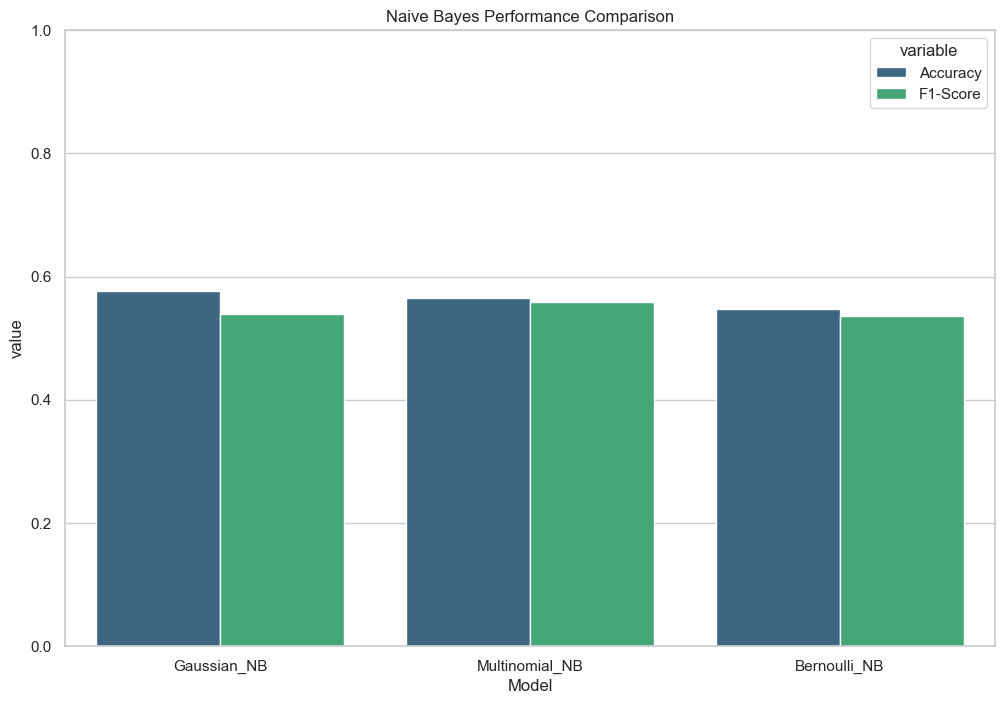

In [4]:
# Define variants
nb_models = {
    "Gaussian_NB": (GaussianNB(), X_train, X_val),
    "Multinomial_NB": (MultinomialNB(), X_train_scaled, X_val_scaled),
    "Bernoulli_NB": (BernoulliNB(), X_train, X_val)
}

comparison_results = []

for name, (model, xt, xv) in nb_models.items():
    model.fit(xt, y_train_cat)
    y_pred = model.predict(xv)
    
    # Storing metrics
    acc = accuracy_score(y_val_cat, y_pred)
    f1 = f1_score(y_val_cat, y_pred, average='macro')
    comparison_results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

# Performance Visualization
perf_df = pd.DataFrame(comparison_results).melt(id_vars="Model")
sns.barplot(data=perf_df, x="Model", y="value", hue="variable", palette="viridis")
plt.title("Naive Bayes Performance Comparison")
plt.ylim(0, 1)
plt.show()

### Describtion: 
This section visualizes the performance metrics of our three candidates. By comparing Accuracy and F1-Score across Gaussian, Multinomial, and Bernoulli variants, we can identify which statistical distribution best maps our apartment features to their respective price segments.

## 2. Detailed Evaluation

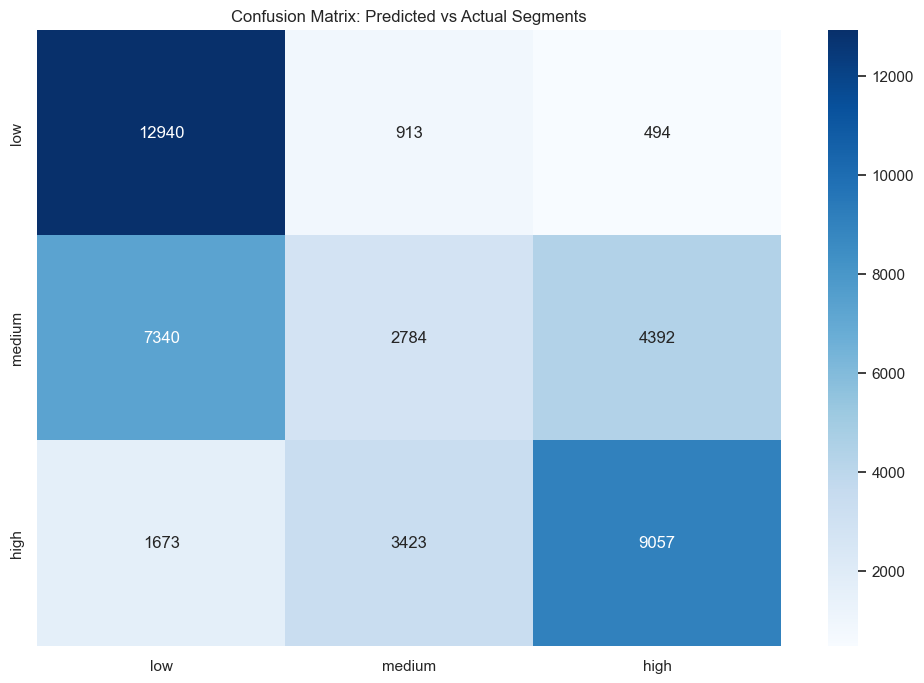

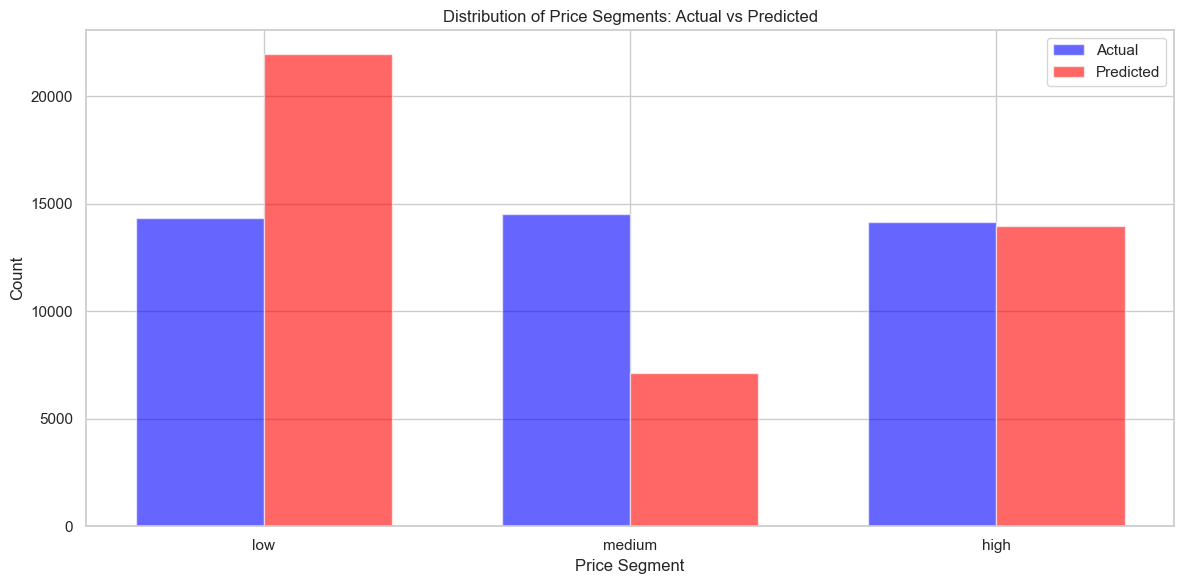


Classification:
              precision    recall  f1-score   support

        high       0.65      0.64      0.64     14153
         low       0.59      0.90      0.71     14347
      medium       0.39      0.19      0.26     14516

    accuracy                           0.58     43016
   macro avg       0.54      0.58      0.54     43016
weighted avg       0.54      0.58      0.54     43016



In [5]:
# Detailed Analysis for Gaussian NB (Primary Model)
best_model = nb_models["Gaussian_NB"][0]
y_final_pred = best_model.predict(X_val)

# Confusion Matrix
cm = confusion_matrix(y_val_cat, y_final_pred, labels=price_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=price_labels, yticklabels=price_labels)
plt.title("Confusion Matrix: Predicted vs Actual Segments")
plt.show()

# Distribution Plot: Actual vs Predicted
plt.figure(figsize=(12, 6))

actual_counts = pd.Series(y_val_cat).value_counts().reindex(price_labels)
pred_counts = pd.Series(y_final_pred).value_counts().reindex(price_labels)

x = range(len(price_labels))
width = 0.35

plt.bar([i - width/2 for i in x], actual_counts, width=width, label='Actual', color='blue', alpha=0.6)
plt.bar([i + width/2 for i in x], pred_counts, width=width, label='Predicted', color='red', alpha=0.6)

plt.xticks(ticks=x, labels=price_labels)
plt.title("Distribution of Price Segments: Actual vs Predicted")
plt.xlabel("Price Segment")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
print("\nClassification:")
print(classification_report(y_val_cat, y_final_pred))

### Describtion:  This section provides an in-depth look at the Gaussian Naive Bayes model, which was identified as the top performer during benchmarking. While overall accuracy provides a general baseline, a granular evaluation is necessary to understand the model's reliability across different price tiers.

### We utilize three primary tools for this evaluation:

- Classification Report: Breaks down performance into Precision (exactness), Recall (completeness), and the F1-Score (harmonic mean) for each specific segment.

- Confusion Matrix (Heatmap): Visualizes the specific "overlap" between classes. It helps identify if the model is making "near-miss" errors (e.g., mistaking a Medium apartment for Low) or "major-error" mistakes (e.g., mistaking High for Low).

- Actual vs. Predicted Distribution: A comparison plot to verify if the model’s predictions maintain the same frequency distribution as the original data, ensuring the model isn't biased toward a specific price category.

### Through this analysis, we can observe that while the model excels at identifying low-price apartments, it faces challenges with the medium segment due to the inherent data overlap in mid-range rental properties.

# ***IV. Conclusion***

### This machine learning pipeline confirms the feasibility of using probabilistic modeling to segment the real estate market based on property attributes. With an accuracy of 58%, the model provides a rapid overview for renters and landlords regarding a property's market position. To overcome the limitations of the independence assumption inherent in Naive Bayes, future research should integrate hyperparameter tuning or expand the dataset to include external factors—such as proximity to public transport or local amenities—to refine precision for premium segments.

Accuracy Score: 0.5808

Classification:
              precision    recall  f1-score   support

        high       0.66      0.64      0.65     17909
         low       0.60      0.90      0.72     18135
      medium       0.38      0.19      0.26     17726

    accuracy                           0.58     53770
   macro avg       0.55      0.58      0.54     53770
weighted avg       0.55      0.58      0.54     53770



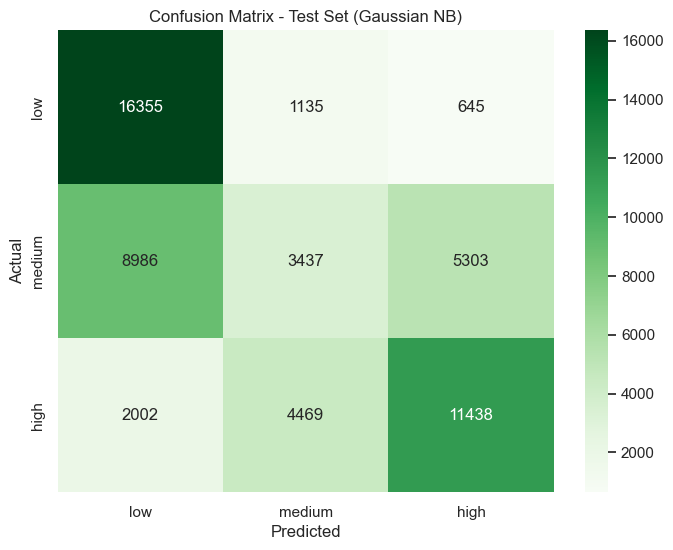

In [6]:
test_df = pd.read_csv('test.csv')
test_price_labels = ['low', 'medium', 'high']
y_test_actual = pd.qcut(test_df['totalRent'], q=3, labels=test_price_labels)

X_test = test_df.drop(columns=['totalRent'])
y_test_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"Accuracy Score: {accuracy_score(y_test_actual, y_test_pred):.4f}")
print("\nClassification:")
print(classification_report(y_test_actual, y_test_pred))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_actual, y_test_pred, labels=test_price_labels), 
            annot=True, fmt='d', cmap='Greens', 
            xticklabels=test_price_labels, yticklabels=test_price_labels)
plt.title('Confusion Matrix - Test Set (Gaussian NB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()